<a href="https://colab.research.google.com/github/Abdukamol0870/Avto/blob/main/3-task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Ma'lumotlarni yuklash

In [3]:
import pandas as pd

url = "https://raw.githubusercontent.com/Abdukamol0870/Avto/main/data_avto.csv"
df = pd.read_csv(url)

df.info()

print(df.describe())

print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ot_kuchi       100 non-null    float64
 1   narxi          100 non-null    float64
 2   yoqilgi_sarfi  100 non-null    float64
 3   yili           100 non-null    int64  
 4   target         100 non-null    int64  
dtypes: float64(3), int64(2)
memory usage: 4.0 KB
         ot_kuchi       narxi  yoqilgi_sarfi         yili      target
count  100.000000  100.000000     100.000000   100.000000  100.000000
mean   161.404000   31.994000      10.656000  2018.060000    0.990000
std     72.520212   21.002717       2.480156     3.727647    0.822598
min     70.800000    7.500000       7.300000  2011.000000    0.000000
25%     85.325000   12.325000       8.300000  2015.000000    0.000000
50%    151.250000   26.300000      10.150000  2018.000000    1.000000
75%    240.525000   52.275000      13.200000  202

KMeans(n_clusters=k) modelini yaratish va har bir obyektga tegishli klasterni ajratish.

In [4]:
from sklearn.cluster import KMeans

X_cluster = df[['ot_kuchi', 'narxi', 'yoqilgi_sarfi']]

k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

df['cluster'] = kmeans.fit_predict(X_cluster)

print(df[['ot_kuchi', 'narxi', 'target', 'cluster']].head())

print(kmeans.cluster_centers_)

   ot_kuchi  narxi  target  cluster
0      74.5    9.2       0        2
1     155.2   28.4       1        0
2     245.8   55.1       2        1
3      82.1   11.5       0        2
4     148.5   24.3       1        0
[[151.70909091  26.53636364  10.24848485]
 [254.40606061  59.51515152  13.81212121]
 [ 80.54705882  10.57941176   7.98823529]]


Klasterlash modellarini yaratish va har bir obyektga tegishli klasslarni ajratish.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

X = df[['ot_kuchi', 'narxi', 'yoqilgi_sarfi', 'yili']]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    "K-NN": KNeighborsClassifier(n_neighbors=5),
    "Logistik Regressiya": LogisticRegression(max_iter=1000),
    "Support Vector Machine": SVC(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}

print(f"{'Algoritm':<25} | {'Aniqlik':<8}")
print("-" * 35)

for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = y_pred

    print(f"{name:<25} | {acc:<8.2f}")

import pandas as pd
comparison_df = pd.DataFrame(results)
comparison_df['Haqiqiy Target'] = y_test.values
print("\nklasslar :")
print(comparison_df.head())

Algoritm                  | Aniqlik 
-----------------------------------
K-NN                      | 1.00    
Logistik Regressiya       | 1.00    
Support Vector Machine    | 0.25    
Decision Tree             | 1.00    
Random Forest             | 1.00    

klasslar :
   K-NN  Logistik Regressiya  Support Vector Machine  Decision Tree  \
0     2                    2                       2              2   
1     2                    2                       2              2   
2     1                    1                       2              1   
3     0                    0                       2              0   
4     2                    2                       2              2   

   Random Forest  Haqiqiy Target  
0              2               2  
1              2               2  
2              1               1  
3              0               0  
4              2               2  


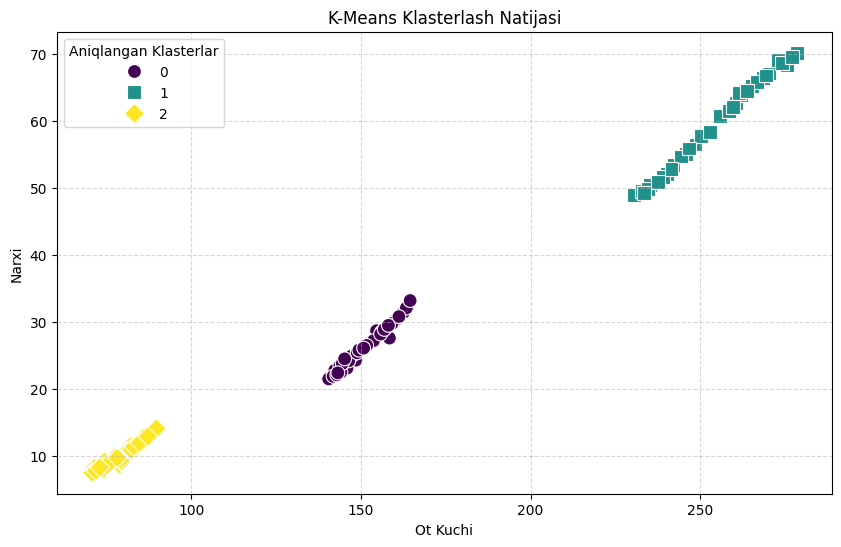

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Grafik o'lchami
plt.figure(figsize=(10, 6))

# Klasterlar grafigi
sns.scatterplot(data=df, x='ot_kuchi', y='narxi', hue='cluster',
                palette='viridis', s=100, style='cluster', markers=['o', 's', 'D'])

# Grafik sarlavhasi va nomlari
plt.title('K-Means Klasterlash Natijasi')
plt.xlabel('Ot Kuchi')
plt.ylabel('Narxi')
plt.legend(title='Aniqlangan Klasterlar')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

/tmp/ipykernel_11123/571904669.py:11: UserWarning: The markers list has more values (3) than needed (1), which may not be intended.
  sns.scatterplot(data=df, x='ot_kuchi', y='narxi', hue='svm_bashorat',


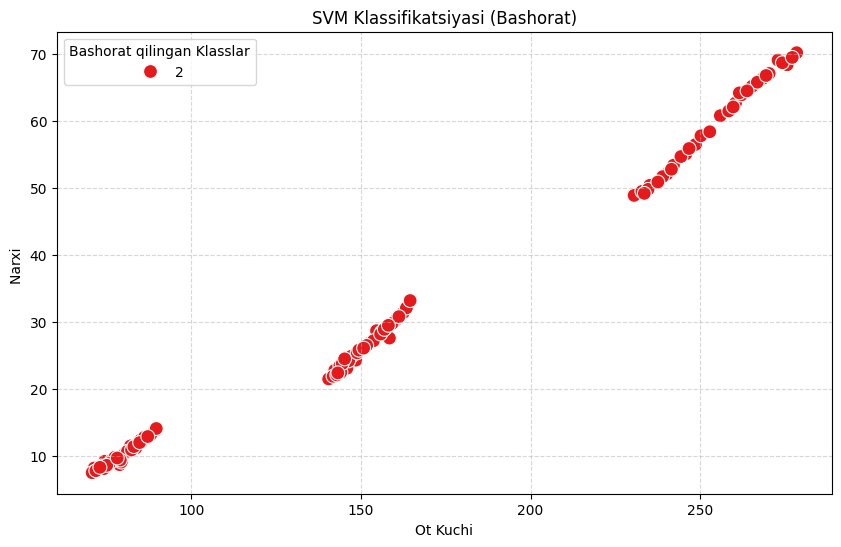

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC

svm_simple = SVC()
svm_simple.fit(X_train, y_train)
df['svm_bashorat'] = svm_simple.predict(X)

plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x='ot_kuchi', y='narxi', hue='svm_bashorat',
                palette='Set1', s=100, style='svm_bashorat', markers=['o', 's', 'D'])

plt.title('SVM Klassifikatsiyasi (Bashorat)')
plt.xlabel('Ot Kuchi')
plt.ylabel('Narxi ')
plt.legend(title='Bashorat qilingan Klasslar')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()